# **Нелинейные модели против южной погоды**

---

**Описание исследования**

Необходимо построить модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов по погодным и календарным условиям. Задача регрессии - предсказать числовое значение целевой переменной по набору факторов, чтобы улучшить точность прогнозов и стабилизировать логистику (избежать дефицита и простоев велосипедов).​

---

**Цель исследования**

Разработать и обучить модель машинного обучения для прогнозирования почасового спроса на велопрокат.

- Целевая переменная: Rented Bike Count (регрессия).
- Базовое решение: оценить предоставленный заказчиком pipeline с линейной регрессией (pickle) на train и test по метрикам RMSE, R^2, MAE.
- Основные модели для улучшения: kNN-регрессия и дерево решений + подбор гиперпараметров через Optuna (подход define-by-run).​
- Основная метрика для оптимизации: RMSE (минимизация); для корректной работы со scoring в cross_val_score использовать neg_root_mean_squared_error 

---

**Задачи исследования**

- Подготовка среды и загрузка данных.
- Запуск baseline-пайплайна с линейной регрессией (pickle) и оценка RMSE/R^2/MAE на train и test.
- EDA и подготовка данных (типы, пропуски, распределение Rented Bike Count, гипотезы о нелинейностях).
- Обучение и подбор гиперпараметров kNN и дерева решений с Optuna.
- Сравнение лучших моделей, выбор победителя и единственная финальная проверка на test.
- Интерпретация (важность признаков) и выводы/рекомендации для BikeSouth.

---

Файлы: ds_s14_train_data.csv (обучение/валидация) и ds_s14_test_data.csv (финальная оценка).

Признаки: 
- погодные (Temperature, Humidity, Windspeed, Visibility, Dew Point Temperature, Solar Radiation, Rainfall, Snowfall)

- сезон/календарь (Seasons, Holiday, Functioning Day)

- временные периоды (Time_Period*, где Daytime - базовый период)

Целевая переменная: Rented Bike Count.

---

## Подготовка среды и библиотек

#### 1.1 Подготовка библиотек


In [62]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU numba numpy scipy scikit-learn==1.6.1 pandas matplotlib seaborn phik joblib category_encoders optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold, RFE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from IPython.display import display

pd.set_option('display.max_columns', None)

In [64]:
print(sklearn.__version__) 

1.6.1


In [65]:
RANDOM_STATE=42

---

In [66]:
def get_df(path):
    return pd.read_csv(path, sep=',', decimal='.')

base_path = '/datasets/'
train_pth1 = Path(f'.{base_path}ds_s14_train_data.csv')
train_pth2 = Path(f'{base_path}ds_s14_train_data.csv')

test_pth1 = Path(f'.{base_path}ds_s14_test_data.csv')
test_pth2 = Path(f'{base_path}ds_s14_test_data.csv')

baseline_pth1 = Path('./models/baseline_linear_regression_pipeline.pkl')
baseline_pth2 = Path(f'{base_path}baseline_linear_regression_pipeline.pkl')

if train_pth1.exists() and test_pth1.exists() and baseline_pth1.exists():
    train = get_df(train_pth1)
    test = get_df(test_pth1)
    baseline = joblib.load(baseline_pth1)
elif train_pth2.exists() and test_pth2.exists() and baseline_pth2.exists():
    train = get_df(train_pth2)
    test = get_df(test_pth2)
    baseline = joblib.load(baseline_pth2)
else:
    raise "Путь до датасета неверный"

In [67]:
print('train')
display(train.head())
train.info()
print()
print('test')
display(test.head())
test.info()

train


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

---

### Разделение данных

In [68]:
X_train_val = train.drop(columns=['Rented Bike Count'])
y_train_val = train['Rented Bike Count']

X_test = test.drop(columns=['Rented Bike Count'])
y_test = test['Rented Bike Count']

print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительного класса в train: {y_train_val.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

Размер обучающей выборки: (7008, 15)
Размер тестовой выборки: (1752, 15)
Доля положительного класса в train: 705.606
Доля положительного класса в test: 700.586


---

### Анализ Baseline модели

In [69]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [70]:
def compute_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

wape_scorer = make_scorer(compute_wape, greater_is_better=False)

In [71]:
def show_metrics(name, pipeline):
    scoring = {
        "RMSE": "neg_root_mean_squared_error",
        "MAE":  "neg_mean_absolute_error",
        "R2":   "r2",
        "WAPE": wape_scorer,
    }

    cv_results = cross_validate(
        pipeline, 
        X_train_val, 
        y_train_val,
        cv=cv, 
        scoring=scoring, 
        n_jobs=5,
    )

    cv_row = {
        "Model": name,
        "RMSE":  -cv_results["test_RMSE"].mean(),
        "MAE":   -cv_results["test_MAE"].mean(),
        "R2":     cv_results["test_R2"].mean(),
        "WAPE%": -cv_results["test_WAPE"].mean(),
    }
    
    metrics_df = pd.DataFrame([cv_row]).round(2)
    
    display(metrics_df)
    return metrics_df

In [72]:
lr_metrics_df = show_metrics('Linear Regression (baseline)', baseline)

,Model,RMSE,MAE,R2,WAPE%
0,Linear Regression (baseline),413.9,310.09,0.59,43.97


---

### EDA анализ

In [73]:
print("Явные дубликаты строк:", train.duplicated().sum())
train = train.drop_duplicates(keep='first')

Явные дубликаты строк: 0


In [74]:
num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['str']).columns
bool_cols = train.select_dtypes(include=['bool']).columns

In [75]:
df_eda = train.copy()

#### Анализ целевой переменной

In [76]:
rbc = df_eda['Rented Bike Count']

rbc.describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

In [77]:
def show_hist(data, name, xlabel='Признак'):    
    ax = data.plot(
        kind='hist',
        title=f'Распределение {name}',
        xlabel=xlabel,
        ylabel='Количетсво',
        rot=30,
        bins=20,
        figsize=(14, 4),
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
    plt.close()

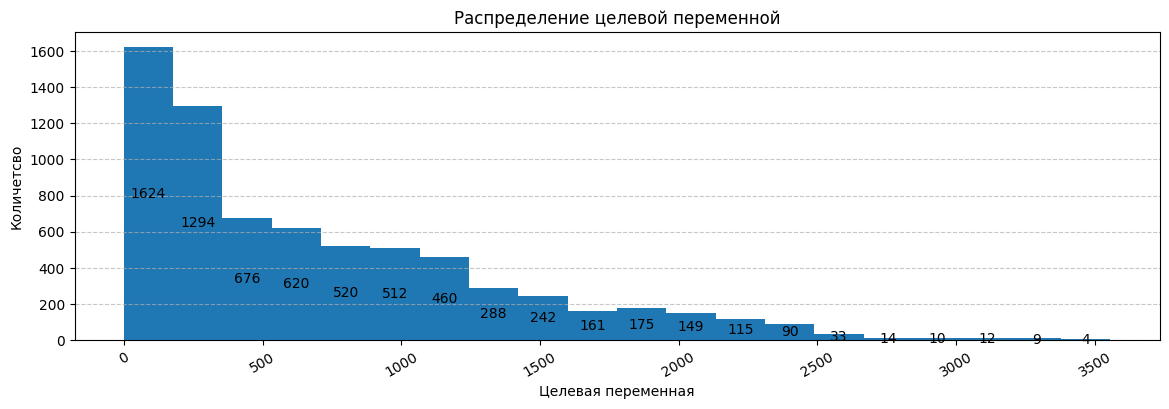

In [78]:
show_hist(rbc, 'целевой переменной', 'Целевая переменная')

#### Анализ числовых признаков

In [79]:
def check_num_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_num_features(df_eda, num_cols)

,Признак,Кол-во
0,Temperature,541
1,Humidity(%),87
2,Wind speed (m/s),64
3,Visibility (10m),1697
4,Dew point temperature,547
5,Solar Radiation (MJ/m2),344
6,Rainfall(mm),53
7,Snowfall (cm),47
8,Rented Bike Count,2024


In [80]:
def create_df_boxplot(data, ax):
    sns.boxplot(data=data, ax=ax)
    
    title = 'Размах значений признака'

    ax.set_title(title)
    ax.set_ylabel('Значение признака')

    ax.grid(True)
    ax.tick_params(axis='x', rotation=30)

In [81]:
def create_df_hist(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    
    hist.set_title(f'Распределение значений признака: {col}')
    hist.set_xlabel('Значение признака')
    hist.set_ylabel('Количество значений')
    hist.set_yscale('log')
    
    create_df_boxplot(data, axes[1])
    
    plt.show()
    plt.close()

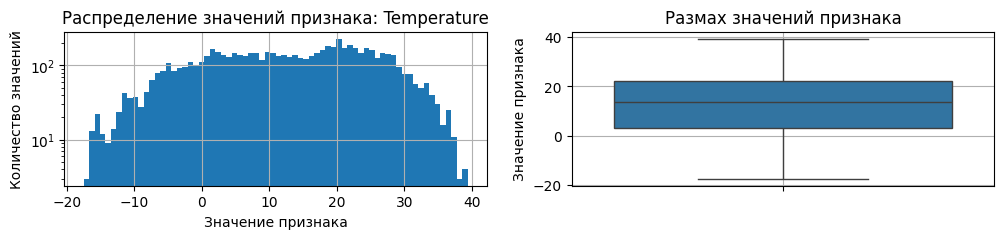

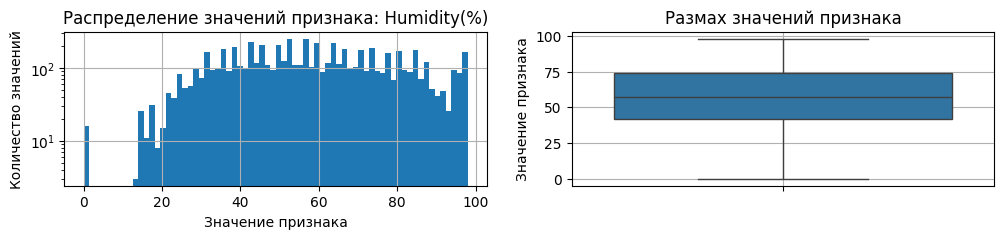

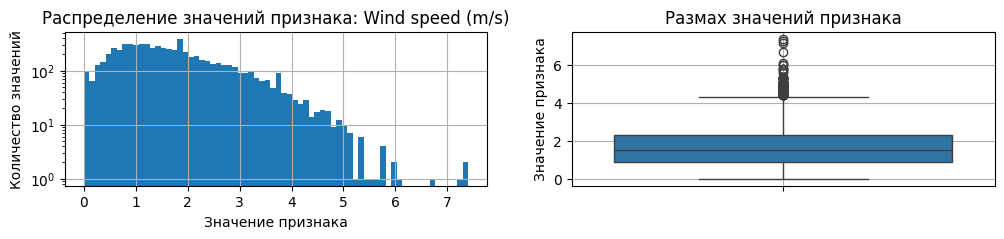

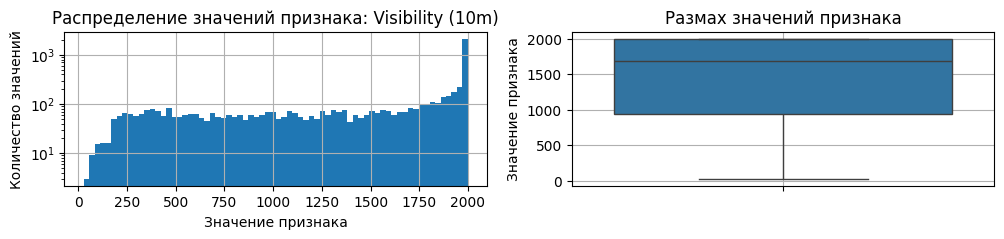

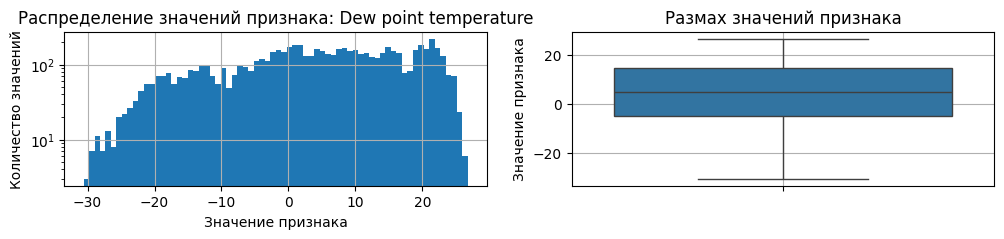

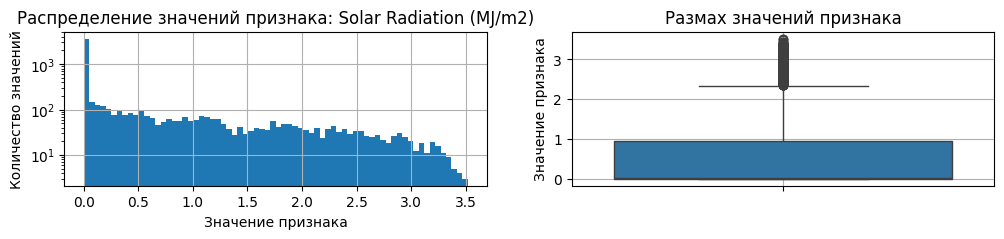

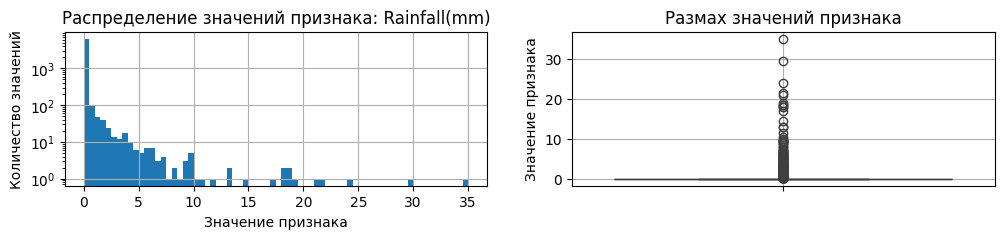

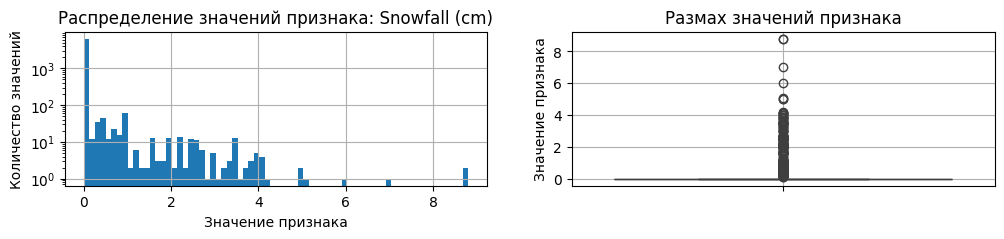

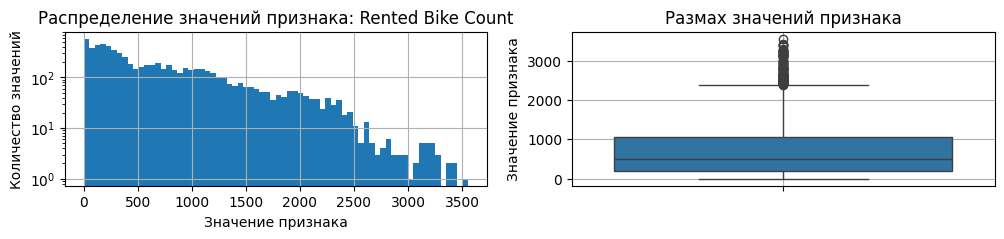

In [82]:
for col in num_cols:
    create_df_hist(df_eda[col], col)

#### Анализ категориальных и бинарных признаков

In [83]:
def check_cat_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_cat_features(df_eda, cat_cols)

,Признак,Уникальные значения,Кол-во
0,Seasons,"[Autumn, Winter, Summer, Spring]",4
1,Holiday,"[Holiday, No Holiday]",2
2,Functioning Day,"[Yes, No]",2


In [84]:
def show_countplot(df_eda, col):
    plt.figure(figsize=(12, 2)) 
    
    ax = sns.countplot(
        x=col,
        data=df_eda,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}')
    plt.xlabel('')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    
    plt.close()

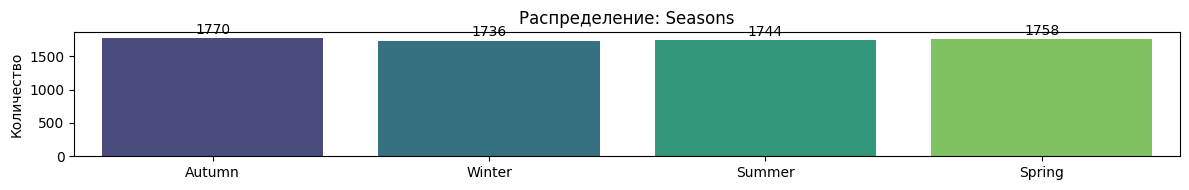

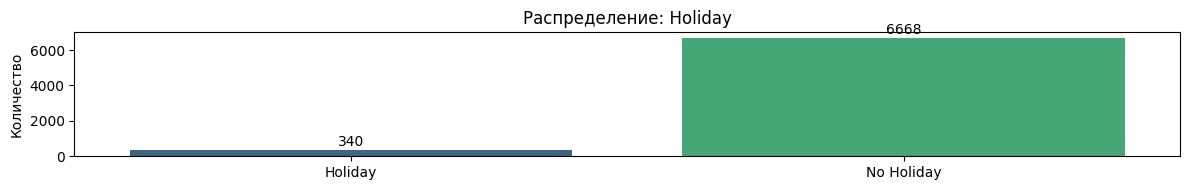

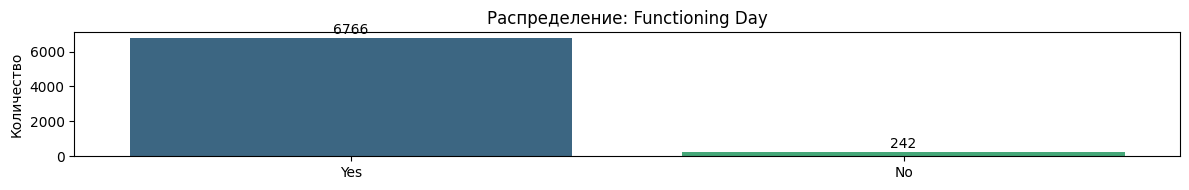

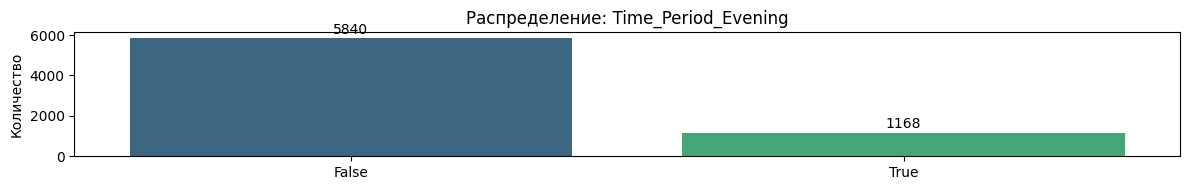

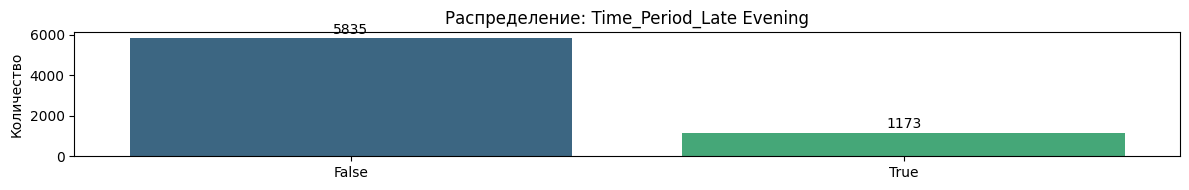

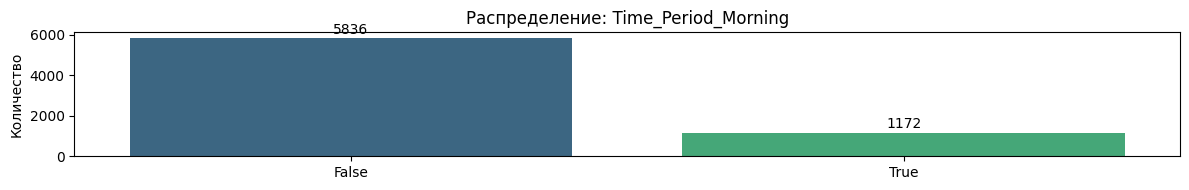

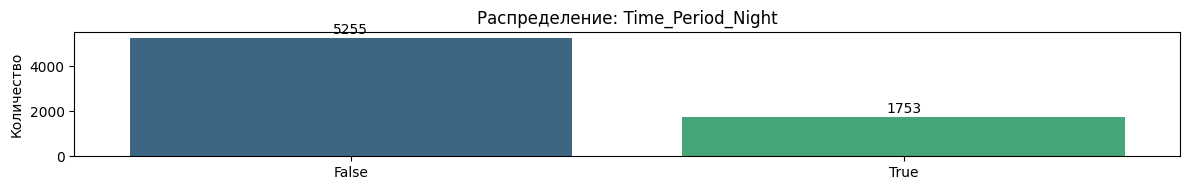

In [85]:
for col in cat_cols.append(bool_cols):
    show_countplot(df_eda, col)

#### Анализ и заполнение пропусков

In [86]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [87]:
show_missing_stats(df_eda)

,Кол-во пропусков,Доля пропусков
Snowfall (cm),263,3.75%
Rainfall(mm),262,3.74%
Visibility (10m),259,3.70%
Humidity(%),250,3.57%
Wind speed (m/s),210,3.00%
Solar Radiation (MJ/m2),210,3.00%


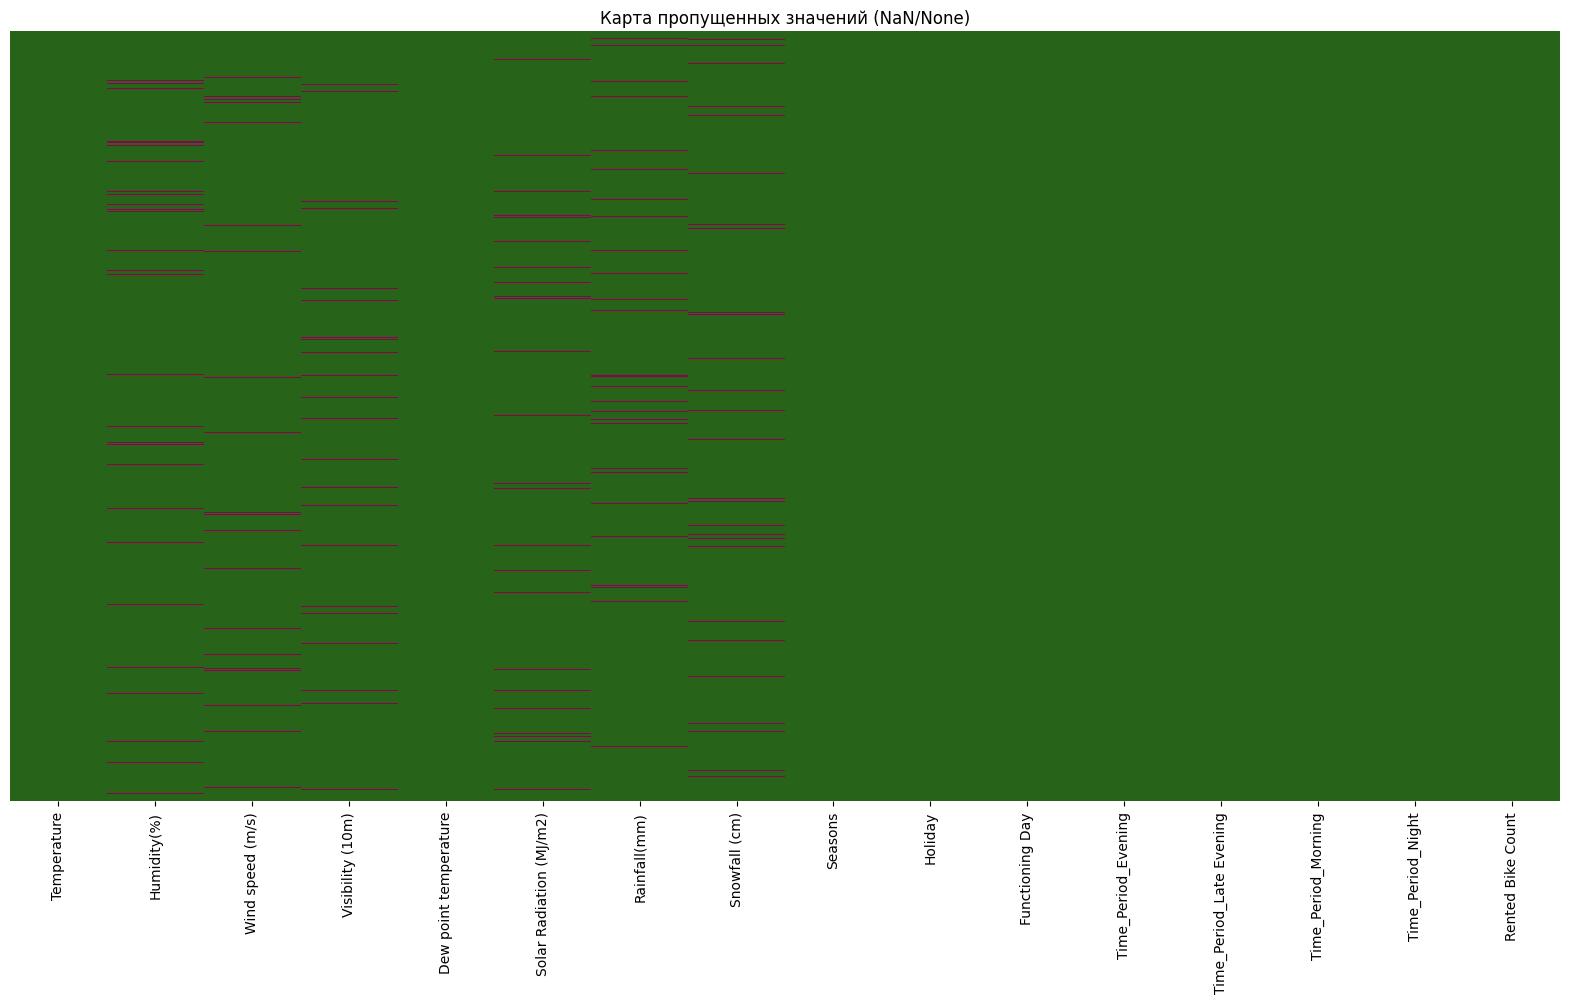

In [88]:
fig, ax = plt.subplots(figsize=(20,10)) 
sns.heatmap(df_eda.isna().astype(int), yticklabels=False, cbar=False, cmap='PiYG_r', xticklabels=df_eda.columns)

plt.title("Карта пропущенных значений (NaN/None)")
plt.show()

In [89]:
cols_to_fix = [
    'Snowfall (cm)', 'Rainfall(mm)', 'Visibility (10m)', 
    'Humidity(%)', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'
]

df_eda[cols_to_fix] = df_eda[cols_to_fix].fillna(df_eda[cols_to_fix].median())

In [90]:
show_missing_stats(df_eda)

'Пропусков в данных нет'

#### Анализ корреляций

In [91]:
def create_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef) 
    plt.figure(figsize=(x, dynamic_height)) 
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )
    
    plt.title(title)

    plt.show()

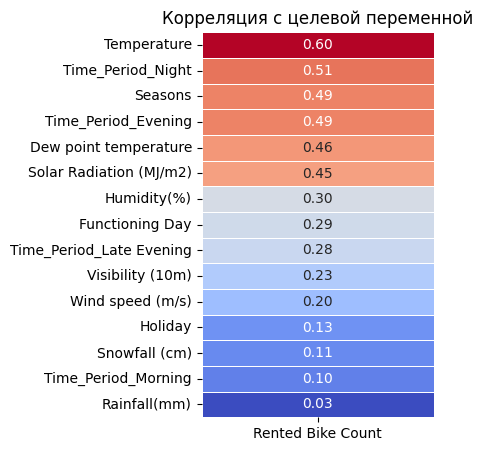

In [92]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

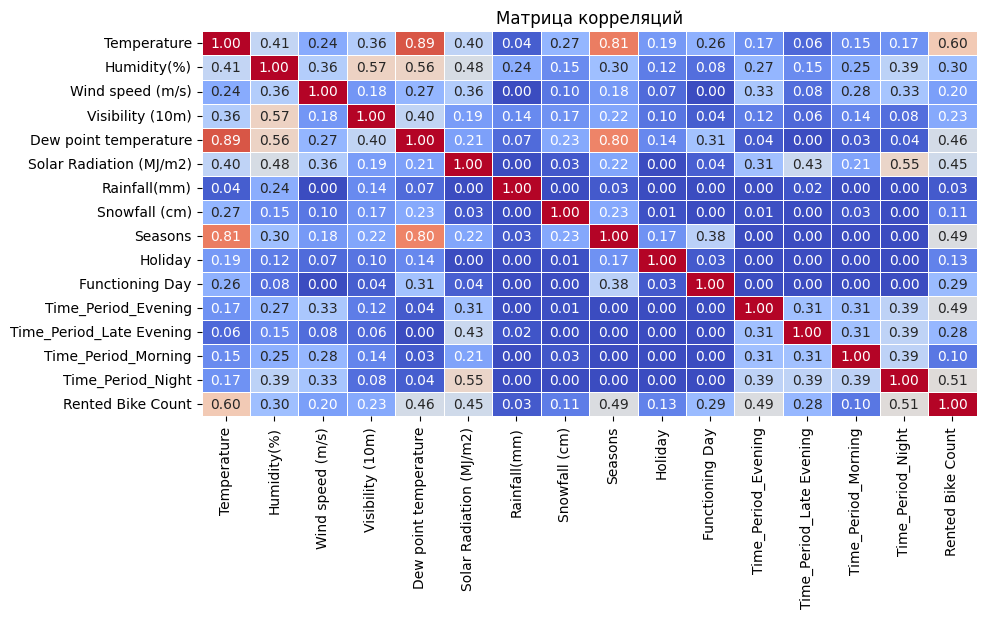

In [93]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

#### Создание полиномов

Для KNN моделей можно проделать логарифмирование, чтобы улучшить распределение и убрать хвосты на графиках.

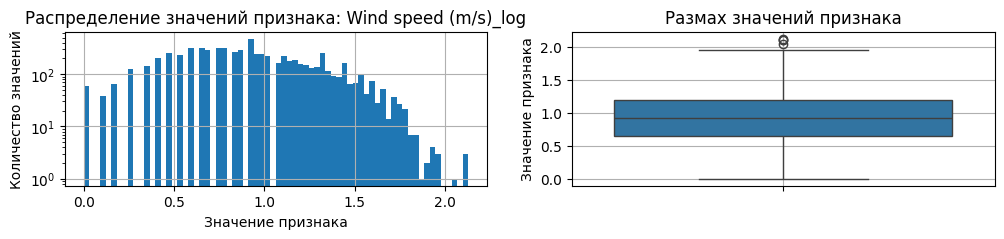

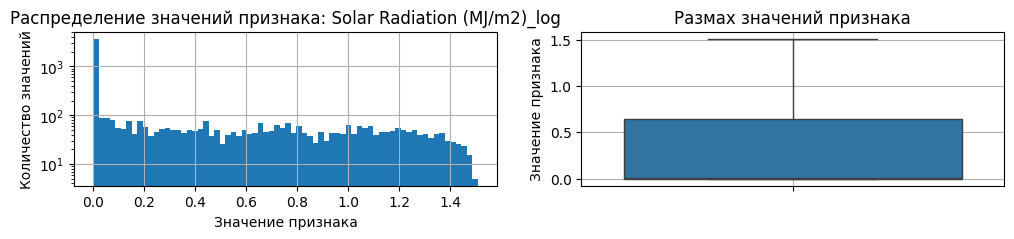

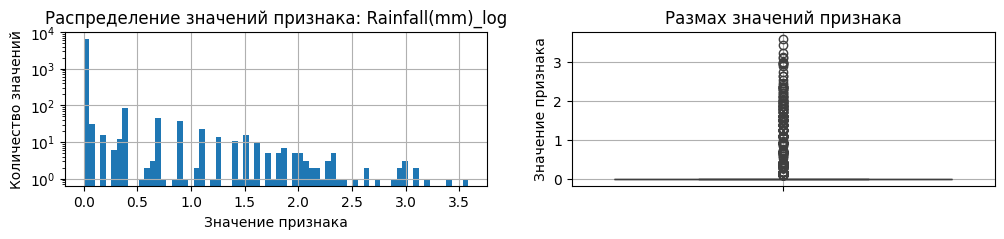

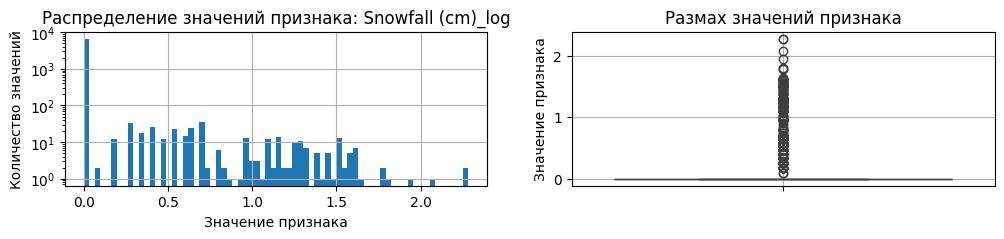

In [94]:
features_with_tails = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
log_col_names = [f'{col}_log' for col in features_with_tails]
df_eda[log_col_names] = df_eda[features_with_tails].apply(np.log1p)

for col in log_col_names:
    create_df_hist(df_eda[col], col)

Для признаков Rainfall и Snowfall логарифмирование не улучшило распределение - удалим признаки _log, но признаки стоит доработать, чтобы модели было проще работать с ними. Стоит преобразовать в категории.

In [95]:
df_eda = df_eda.drop(columns=['Rainfall(mm)_log', 'Snowfall (cm)_log', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'])

#### Создание категориальных признаков

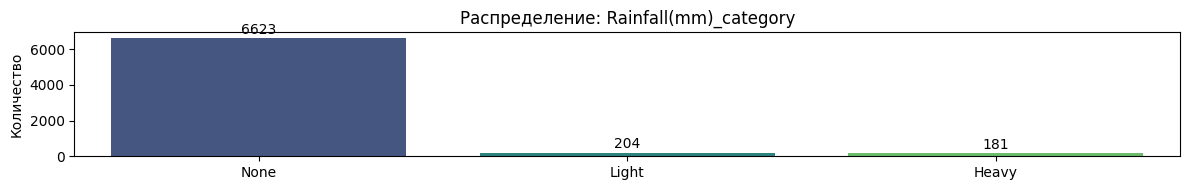

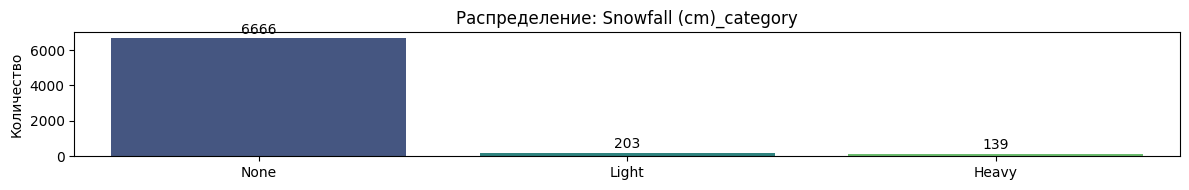

In [96]:
for col in ['Rainfall(mm)', 'Snowfall (cm)']:
    new_col = f"{col}_category"

    df_eda[new_col] = pd.cut(df_eda[col], 
                             bins=[-np.inf, 0, 1, np.inf], 
                             labels=['None', 'Light', 'Heavy'])
    
    df_eda = df_eda.drop(columns=[col])
    
    show_countplot(df_eda, new_col)

#### Повторный анализ корреляции

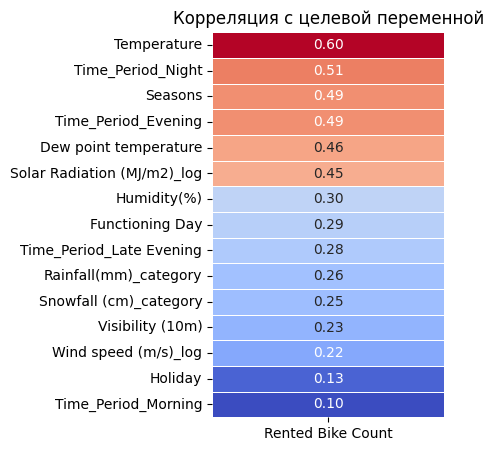

In [97]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rented Bike Count', 'Wind speed (m/s)_log', 'Solar Radiation (MJ/m2)_log'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

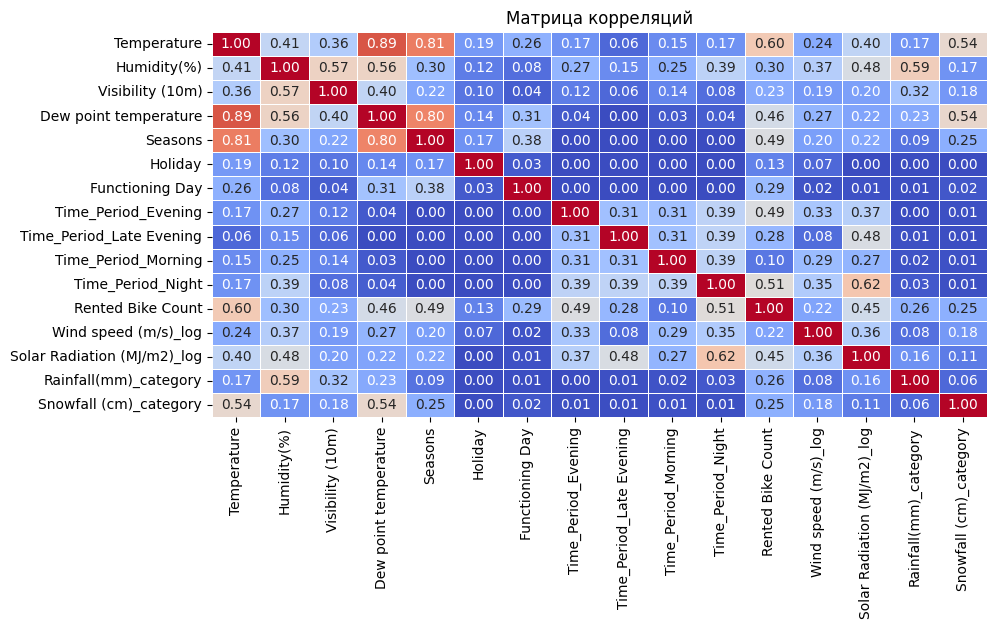

In [98]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Для KNN важно избавиться от корреляции между признаками, поэтому данные столбцы не будут удалены сразу, а только при обучении моделей KNN. Оставить стоит только Temperature, так как данный признак имеет наибольшую корреляция с таргетом. Удаляться будут: 'Seasons', 'Dew point temperature'.

Вывод: обработаны пропуски в погодных числовых признаках (~3–3.75%) заполнением медианой, изучено распределение таргета (правосторонняя асимметрия с "хвостом") и корреляции. Для KNN рассмотрены преобразования: логарифмирование, при этом для Rainfall/Snowfall оно не помогло - признаки планируются к категоризации; также для снижения мультиколлинеарности в KNN-ветке оставляется Temperature, а Seasons и Dew point temperature исключаются. Дополнительно добавлены полиномиальные признаки и новые категории из числовых признаков, что улучшило корреляции и позволило лучше учитывать нелинейные зависимости.

---

### Обучение моделей

#### Создание KNN моделей

In [99]:
target = ['Rented Bike Count']
correlating_features = ['Seasons', 'Dew point temperature']

log_features = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)']
fall_features = ['Rainfall(mm)', 'Snowfall (cm)']

In [100]:
num_cols = [col for col in num_cols if col not in target]
cat_cols = [col for col in cat_cols if col not in target]
bool_cols = [col for col in bool_cols if col not in target]

In [101]:
knn_num_cols = [col for col in num_cols if col not in correlating_features + log_features + fall_features]
knn_cat_cols = [col for col in cat_cols if col not in correlating_features]
knn_bool_cols = [col for col in bool_cols if col not in correlating_features]

In [102]:
def bool_to_int(df):
    return df.astype(int)

In [103]:
def fall_binning(X):
    X_df = X.copy()
    for col in X_df.columns:
        X_df[col] = pd.cut(
            X_df[col], 
            bins=[-np.inf, 0, 1, np.inf], 
            labels=['None', 'Light', 'Heavy'],
        )
    return X_df

def get_fall_feature_names(transformer, input_features):
    return input_features 

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('log', make_pipeline(
                SimpleImputer(strategy='constant', fill_value=0),
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                StandardScaler()
        ), log_features),
        
        ('num', make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ), knn_num_cols),
        
        ('fall', make_pipeline(
            FunctionTransformer(fall_binning, feature_names_out=get_fall_feature_names),
            OneHotEncoder(drop='first', sparse_output=False),
        ), fall_features),
        
        ('cat', OneHotEncoder(drop='first', sparse_output=False), knn_cat_cols),
        
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), knn_bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [104]:
X_transformed_df = knn_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,log__Wind speed (m/s),log__Solar Radiation (MJ/m2),num__Temperature,num__Humidity(%),num__Visibility (10m),fall__Rainfall(mm)_Light,fall__Rainfall(mm)_None,fall__Rainfall(mm)_nan,fall__Snowfall (cm)_Light,fall__Snowfall (cm)_None,fall__Snowfall (cm)_nan,cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
0,0.793466,0.120652,0.627909,-1.159392,0.928943,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1,0,0,0
1,1.318292,-0.411292,1.055624,-0.158090,0.928943,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1,0,0,0
2,0.127182,-0.722786,-1.653236,-0.959132,0.928943,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
3,0.642894,-0.722786,-1.510664,-1.059262,0.928943,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,1
4,0.564040,2.275928,0.887893,-1.209457,0.928943,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,0


In [105]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),
    ('model', KNeighborsRegressor())
])

knn_baseline_metrics_df = show_metrics('KNN (baseline)', knn_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,KNN (baseline),339.53,232.23,0.72,32.92


In [106]:
rf_estimator = Ridge(random_state=RANDOM_STATE)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),

    ('var_thresh', VarianceThreshold(threshold=0.001)),
    ('correlation_filter', SelectKBest(score_func=f_regression, k='all')),
    ('rfe', RFE(estimator=rf_estimator, n_features_to_select=.8, step=2)),

    ('model', KNeighborsRegressor())
])

knn_filted_metrics_df = show_metrics('KNN (filted)', knn_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,KNN (filted),323.03,215.16,0.75,30.51


In [107]:
def objective(trial):
    params = {
        "n_neighbors": trial.suggest_int('n_neighbors', 2, 100),
        "weights": trial.suggest_categorical('weights', ['uniform', 'distance']),
        "p": trial.suggest_int('p', 1, 6)
    }

    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)

    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )
    
    mean_score = scores.mean()

    trial.report(mean_score, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

knn_best_params = study.best_params
print("Лучшие гиперпараметры:", knn_best_params)
knn_best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(knn_best_value, 3))

[I 2026-02-15 17:36:49,595] A new study created in memory with name: no-name-7aff66b9-149d-4809-80a7-f9db4bdc0257
Best trial: 3. Best value: 340.614:   1%|          | 1/100 [00:00<01:16,  1.30it/s]

[I 2026-02-15 17:36:50,363] Trial 3 finished with value: 340.6135664471181 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1}. Best is trial 3 with value: 340.6135664471181.


Best trial: 3. Best value: 340.614:   3%|▎         | 3/100 [00:01<00:37,  2.60it/s]

[I 2026-02-15 17:36:50,795] Trial 1 finished with value: 342.3178318440973 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 4}. Best is trial 3 with value: 340.6135664471181.
[I 2026-02-15 17:36:50,961] Trial 2 finished with value: 368.2863323372709 and parameters: {'n_neighbors': 36, 'weights': 'uniform', 'p': 4}. Best is trial 3 with value: 340.6135664471181.


Best trial: 3. Best value: 340.614:   3%|▎         | 3/100 [00:01<00:37,  2.60it/s]

...

Best trial: 91. Best value: 329.51:  95%|█████████▌| 95/100 [00:23<00:00,  8.31it/s]

[I 2026-02-15 17:37:12,714] Trial 92 finished with value: 332.3203526643981 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'p': 1}. Best is trial 91 with value: 329.50966855738614.
[I 2026-02-15 17:37:12,729] Trial 93 finished with value: 331.98032657785853 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 91 with value: 329.50966855738614.
[I 2026-02-15 17:37:12,736] Trial 94 finished with value: 332.3203526643981 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'p': 1}. Best is trial 91 with value: 329.50966855738614.
[I 2026-02-15 17:37:12,753] Trial 95 finished with value: 331.98032657785853 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 91 with value: 329.50966855738614.


Best trial: 91. Best value: 329.51: 100%|██████████| 100/100 [00:23<00:00,  4.23it/s]

[I 2026-02-15 17:37:13,153] Trial 96 finished with value: 331.98032657785853 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 91 with value: 329.50966855738614.
[I 2026-02-15 17:37:13,200] Trial 97 pruned. 
[I 2026-02-15 17:37:13,202] Trial 99 finished with value: 329.50966855738614 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 1}. Best is trial 91 with value: 329.50966855738614.
[I 2026-02-15 17:37:13,244] Trial 98 pruned. 


Лучшие гиперпараметры: {'n_neighbors': 11, 'weights': 'distance', 'p': 1}
Лучшее среднее значение RMSE на кросс-валидации: 329.51


In [108]:
model = KNeighborsRegressor(**study.best_params)
knn_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("model", model)
])

knn_best_metrics_df = show_metrics('KNN (best params)', knn_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,KNN (best params),329.52,227.92,0.74,32.31


---

#### Создание деревьев

In [109]:
def show_tree_plot(name, pipeline):
    tree_model = pipeline.named_steps["model"]
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    _, ax = plt.subplots(1, 1, figsize=(26, 12))
    plot_tree(
        tree_model,
        ax=ax,
        filled=True,
        rounded=True,
        feature_names=feature_names,
        fontsize=12,
        max_depth=3,
        impurity=False,
        precision=2 
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

In [110]:
def show_feature_importance(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    feature_importance = pd.DataFrame(
        {
            "feature": preprocessor.get_feature_names_out(),
            "importance": model.feature_importances_ * 100,
        }
    ).sort_values("importance", ascending=False)

    display(feature_importance \
            .style.format({'importance': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm'))
    
    top_5_feature_names = feature_importance['feature'].values[:5]
    top_5_feature_importance = feature_importance['importance'].values[:5]

    plt.figure(figsize=(8, 5))
    plt.barh(top_5_feature_names, top_5_feature_importance, color='lightseagreen')
    plt.xlabel('Важность признака')
    plt.title('Важность признаков в дереве решений')
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

In [111]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [112]:
X_transformed_df = tree_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,num__Temperature,num__Humidity(%),num__Wind speed (m/s),num__Visibility (10m),num__Dew point temperature,num__Solar Radiation (MJ/m2),num__Rainfall(mm),num__Snowfall (cm),cat__Seasons_Spring,cat__Seasons_Summer,cat__Seasons_Winter,cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,0
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1,0,0,0
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0,1,0,0
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0,0,0,1
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0,0,0


In [113]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

name = 'Decision Tree Regressor (baseline)'
dtr_baseline_metrics_df = show_metrics(name, tree_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,Decision Tree Regressor (baseline),397.16,247.24,0.62,35.05


In [114]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 2, 100),  
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"])
    }

    model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)
    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    mean_score = scores.mean()

    trial.report(mean_score, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

tree_best_params = study.best_params
print("Лучшие гиперпараметры:", tree_best_params)
tree_best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(tree_best_value, 3))

[I 2026-02-15 17:37:13,532] A new study created in memory with name: no-name-ffd70acf-cf7c-4231-8335-b7b68a44d1d6
Best trial: 0. Best value: 325.264:   3%|▎         | 3/100 [00:00<00:06, 14.18it/s]

[I 2026-02-15 17:37:13,633] Trial 3 finished with value: 445.5744292765871 and parameters: {'max_depth': 28, 'min_samples_split': 4, 'min_samples_leaf': 11, 'max_leaf_nodes': 7, 'ccp_alpha': 0.09931917100857364, 'max_features': 'log2', 'criterion': 'squared_error'}. Best is trial 3 with value: 445.5744292765871.
[I 2026-02-15 17:37:13,682] Trial 0 finished with value: 325.26372611738753 and parameters: {'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_leaf_nodes': 75, 'ccp_alpha': 0.09465323131184948, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 0 with value: 325.26372611738753.
[I 2026-02-15 17:37:13,754] Trial 5 finished with value: 358.1032239265345 and parameters: {'max_depth': 34, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_leaf_nodes': 53, 'ccp_alpha': 0.06543334243547418, 'max_features': 'sqrt', 'criterion': 'squared_error'}. Best is trial 0 with value: 325.26372611738753.
[I 2026-02-15 17:37:13,816] Trial 6 finished with valu

Best trial: 0. Best value: 325.264:   5%|▌         | 5/100 [00:00<00:07, 12.30it/s]

[I 2026-02-15 17:37:13,936] Trial 7 finished with value: 328.21790689563625 and parameters: {'max_depth': 16, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_leaf_nodes': 100, 'ccp_alpha': 0.03409689255702423, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 0 with value: 325.26372611738753.


Best trial: 0. Best value: 325.264:   7%|▋         | 7/100 [00:01<00:16,  5.60it/s]

...

Best trial: 85. Best value: 321.728:  94%|█████████▍| 94/100 [00:10<00:01,  4.26it/s]

[I 2026-02-15 17:37:23,485] Trial 92 pruned. 
[I 2026-02-15 17:37:23,516] Trial 90 pruned. 
[I 2026-02-15 17:37:23,623] Trial 94 finished with value: 321.871128498842 and parameters: {'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 20, 'max_leaf_nodes': 94, 'ccp_alpha': 0.08157349351841223, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 321.72833241643895.
[I 2026-02-15 17:37:23,633] Trial 91 pruned. 
[I 2026-02-15 17:37:23,661] Trial 95 pruned. 


Best trial: 99. Best value: 321.151: 100%|██████████| 100/100 [00:10<00:00,  9.68it/s]


[I 2026-02-15 17:37:23,695] Trial 93 pruned. 
[I 2026-02-15 17:37:23,815] Trial 96 finished with value: 321.9980378452272 and parameters: {'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 19, 'max_leaf_nodes': 94, 'ccp_alpha': 0.08135088122223322, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 321.72833241643895.
[I 2026-02-15 17:37:23,831] Trial 97 pruned. 
[I 2026-02-15 17:37:23,854] Trial 98 finished with value: 322.226839213325 and parameters: {'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 19, 'max_leaf_nodes': 94, 'ccp_alpha': 0.09086192144149184, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 85 with value: 321.72833241643895.
[I 2026-02-15 17:37:23,859] Trial 99 finished with value: 321.15102905610286 and parameters: {'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 19, 'max_leaf_nodes': 94, 'ccp_alpha': 0.0694254897332365, 'max_features': None, 'criterion': 'squared_error'}. Best is tr

Лучшие гиперпараметры: {'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 19, 'max_leaf_nodes': 94, 'ccp_alpha': 0.0694254897332365, 'max_features': None, 'criterion': 'squared_error'}
Лучшее среднее значение RMSE на кросс-валидации: 321.151


In [116]:
model = DecisionTreeRegressor(**study.best_params)
tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", model)
])

name = 'Decision Tree Regressor (best params)'
dtr_best_metrics_df = show_metrics(name, tree_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,Decision Tree Regressor (best params),321.15,217.63,0.75,30.87


#### Создание bagging моделей

In [118]:
bagging_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

rfr_baseline_metrics_df = show_metrics('Random Forest Regressor (baseline)', bagging_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,Random Forest Regressor (baseline),288.29,188.57,0.8,26.73


In [119]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 35),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 0.1, log=True),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]) 
    }

    model = RandomForestRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)
    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    mean_score = scores.mean()

    trial.report(mean_score, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 
bagging_best_params = study.best_params
print("Лучшие гиперпараметры:", bagging_best_params)
bagging_best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(bagging_best_value, 3))

[I 2026-02-15 17:37:52,087] A new study created in memory with name: no-name-0b12f663-44ac-4e82-8414-d43c2bcec416
Best trial: 2. Best value: 304.392:   3%|▎         | 1/30 [00:03<01:28,  3.07s/it]

[I 2026-02-15 17:37:55,153] Trial 2 finished with value: 304.3921968102588 and parameters: {'n_estimators': 200, 'max_depth': 22, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True, 'ccp_alpha': 0.0024580260582405975, 'criterion': 'friedman_mse'}. Best is trial 2 with value: 304.3921968102588.


Best trial: 1. Best value: 293:   7%|▋         | 2/30 [00:03<00:40,  1.44s/it]    

[I 2026-02-15 17:37:55,449] Trial 1 finished with value: 293.00012220154247 and parameters: {'n_estimators': 149, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False, 'ccp_alpha': 0.00010408921873857498, 'criterion': 'squared_error'}. Best is trial 1 with value: 293.00012220154247.


Best trial: 1. Best value: 293:  10%|█         | 3/30 [00:04<00:39,  1.46s/it]

...

Best trial: 20. Best value: 281.734:  97%|█████████▋| 29/30 [01:05<00:01,  1.83s/it]

[I 2026-02-15 17:38:57,308] Trial 28 finished with value: 282.7971604348503 and parameters: {'n_estimators': 292, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'ccp_alpha': 0.006466070807364422, 'criterion': 'squared_error'}. Best is trial 20 with value: 281.73423373842627.


Best trial: 20. Best value: 281.734: 100%|██████████| 30/30 [01:05<00:00,  2.19s/it]

[I 2026-02-15 17:38:57,924] Trial 29 finished with value: 282.0573934211503 and parameters: {'n_estimators': 289, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'ccp_alpha': 0.007086930974023327, 'criterion': 'squared_error'}. Best is trial 20 with value: 281.73423373842627.


Лучшие гиперпараметры: {'n_estimators': 269, 'max_depth': 22, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False, 'ccp_alpha': 1.0385838673863545e-05, 'criterion': 'squared_error'}
Лучшее среднее значение RMSE на кросс-валидации: 281.734


In [121]:
model = RandomForestRegressor(**study.best_params)
bagging_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", model)
])

rfr_best_metrics_df = show_metrics('Random Forest Regressor (best params)', bagging_pipeline)

,Model,RMSE,MAE,R2,WAPE%
0,Random Forest Regressor (best params),282.39,188.43,0.81,26.71


---

,Model,RMSE,MAE,R2,WAPE%
7,Random Forest Regressor (best params),282.39,188.43,0.81,26.71
6,Random Forest Regressor (baseline),288.29,188.57,0.80,26.73
5,Decision Tree Regressor (best params),321.15,217.63,0.75,30.87
2,KNN (filted),323.03,215.16,0.75,30.51
3,KNN (best params),329.52,227.92,0.74,32.31
1,KNN (baseline),339.53,232.23,0.72,32.92
4,Decision Tree Regressor (baseline),397.16,247.24,0.62,35.05
0,Linear Regression (baseline),413.90,310.09,0.59,43.97


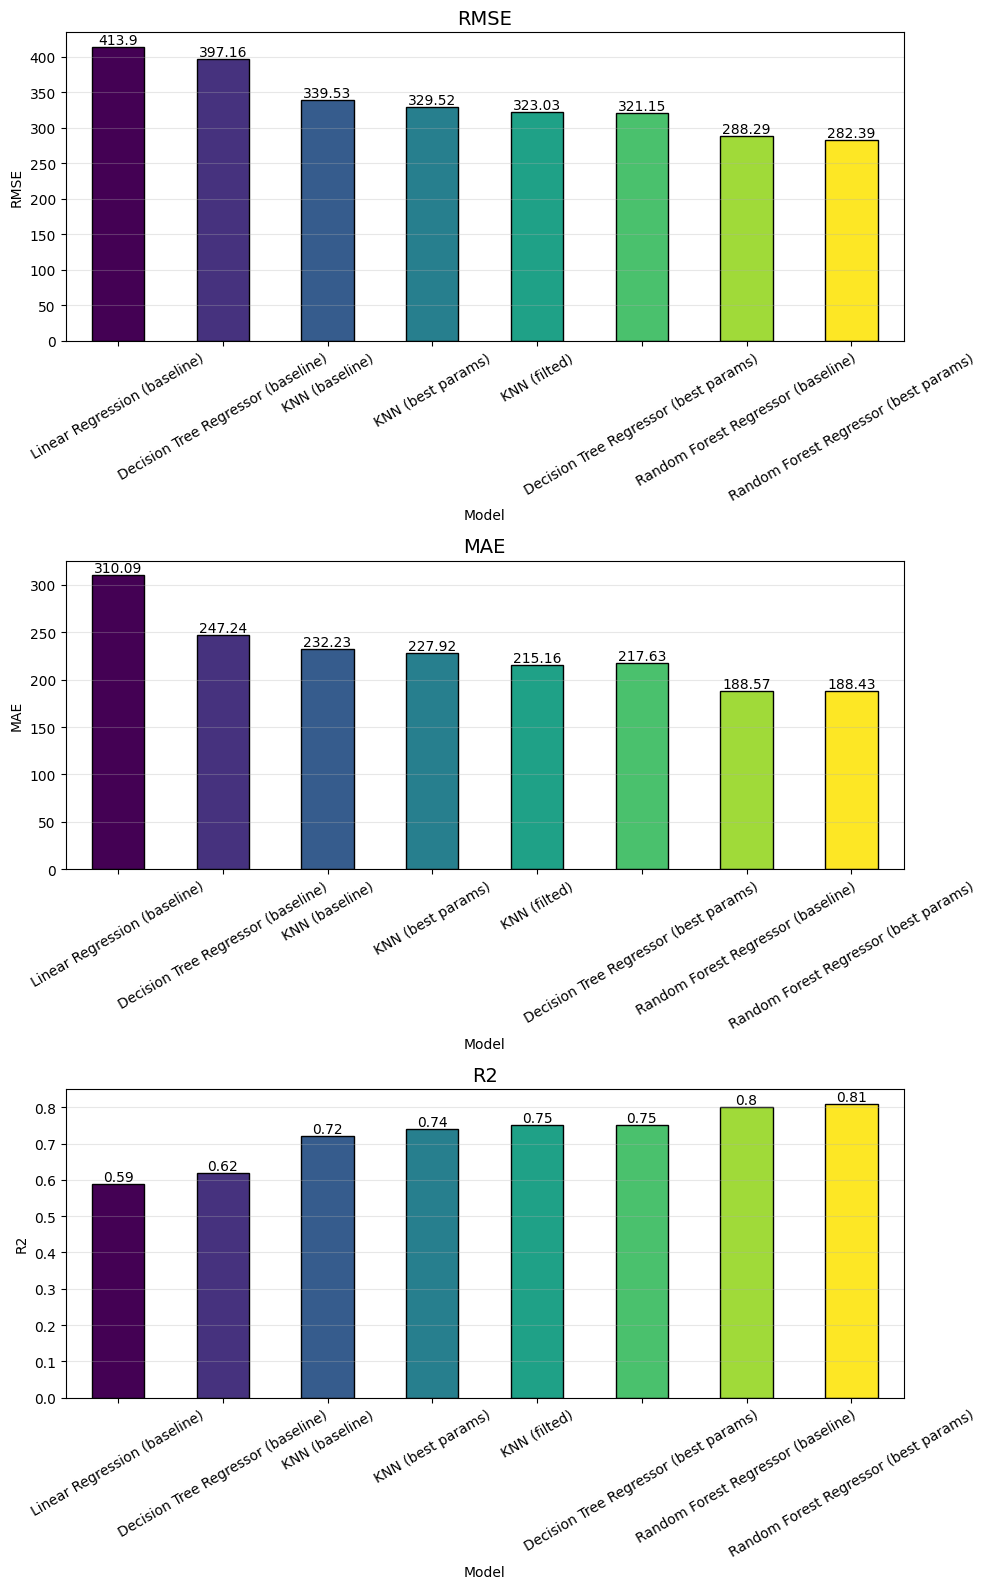

In [122]:
summary_df = pd.concat(
    [
        lr_metrics_df, 
        knn_baseline_metrics_df, 
        knn_filted_metrics_df, 
        knn_best_metrics_df, 
        dtr_baseline_metrics_df, 
        dtr_best_metrics_df, 
        rfr_baseline_metrics_df, 
        rfr_best_metrics_df
    ], ignore_index=True,
).sort_values(by="RMSE", ascending=False)

display(summary_df.sort_values(by="RMSE", ascending=True))

test_df = summary_df.set_index("Model")

fig, axes = plt.subplots(3, 1, figsize=(10, 16))
cmap = plt.get_cmap('viridis')
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    colors = cmap(np.linspace(0, 1, len(test_df)))
    test_df[metric].plot.bar(ax=ax, edgecolor="black", color=colors)
    
    ax.set_title(metric, fontsize=14)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.bar_label(ax.containers[0])
    
plt.tight_layout()
plt.show()

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Test,Decision Tree,321.72,216.96,0.75,30.97


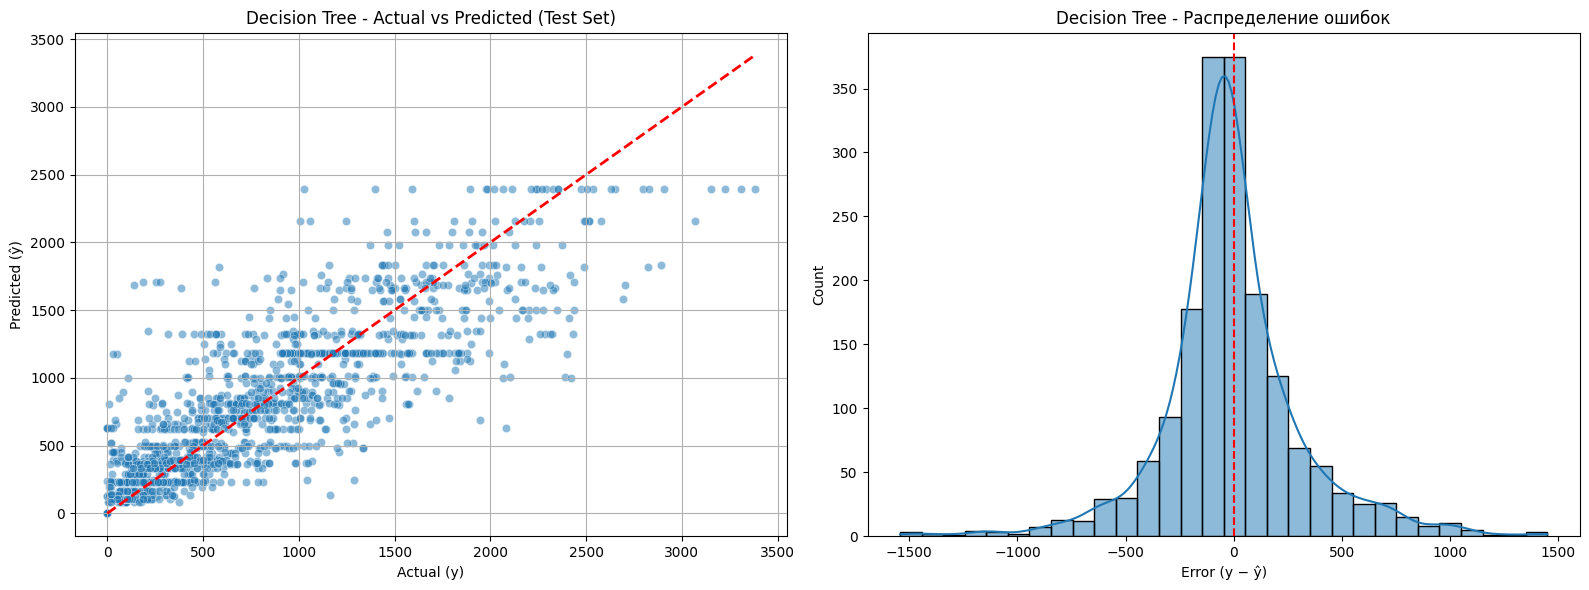

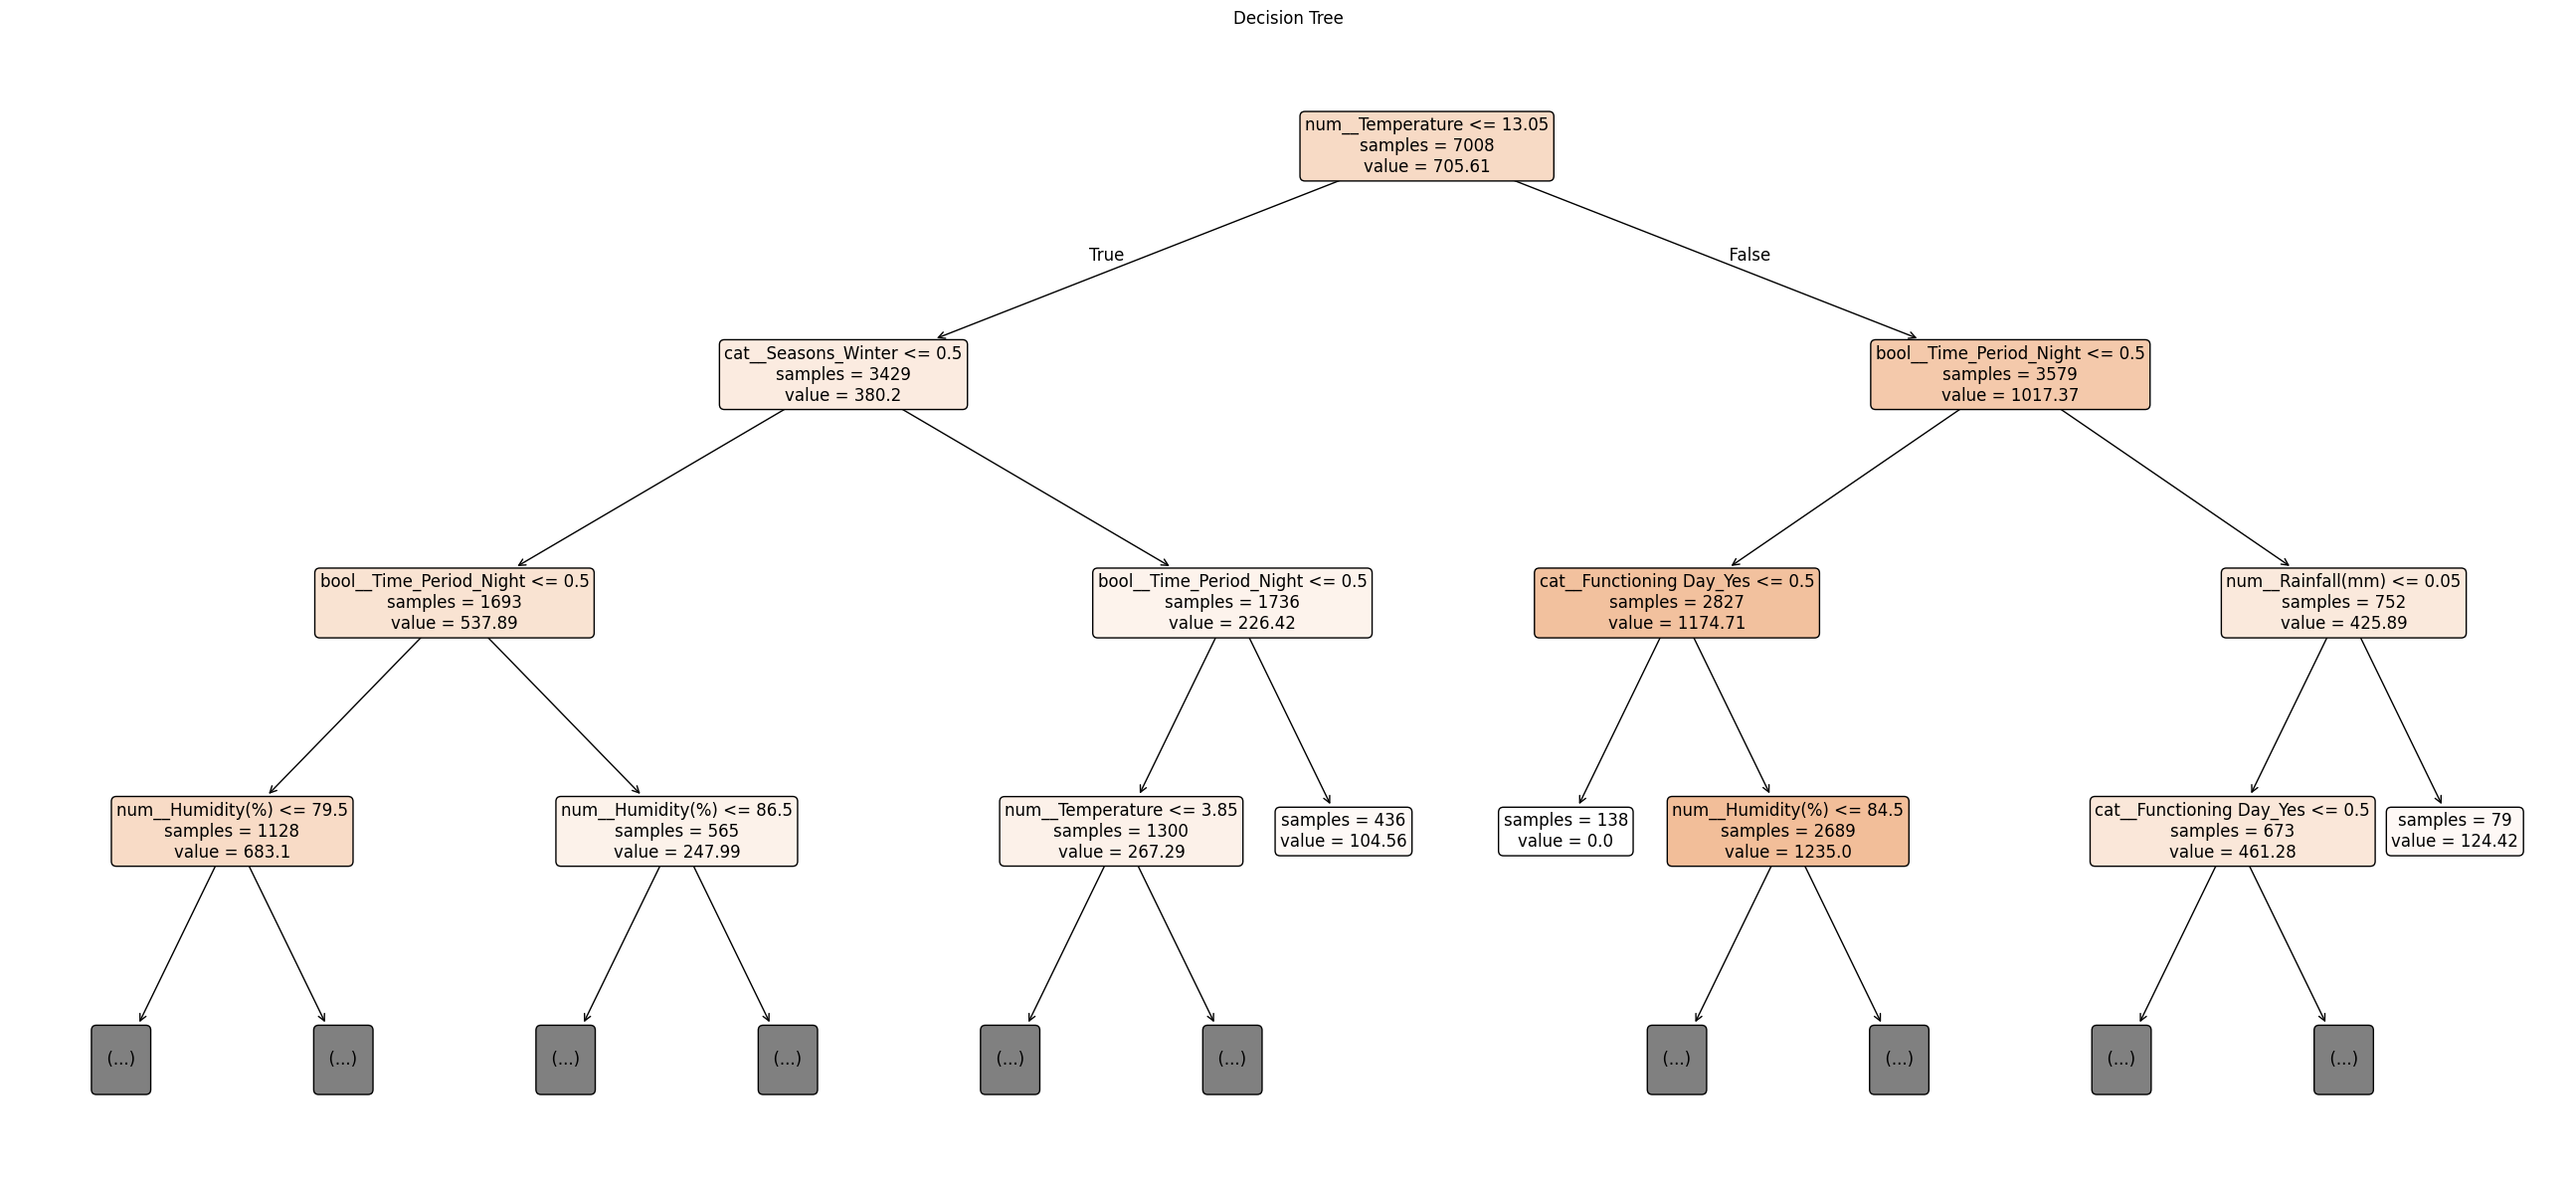

,feature,importance
0,num__Temperature,35.18%
16,bool__Time_Period_Night,17.56%
1,num__Humidity(%),12.10%
12,cat__Functioning Day_Yes,9.77%
13,bool__Time_Period_Evening,9.01%
14,bool__Time_Period_Late Evening,4.74%
10,cat__Seasons_Winter,3.54%
5,num__Solar Radiation (MJ/m2),3.33%
4,num__Dew point temperature,1.58%
8,cat__Seasons_Spring,1.14%


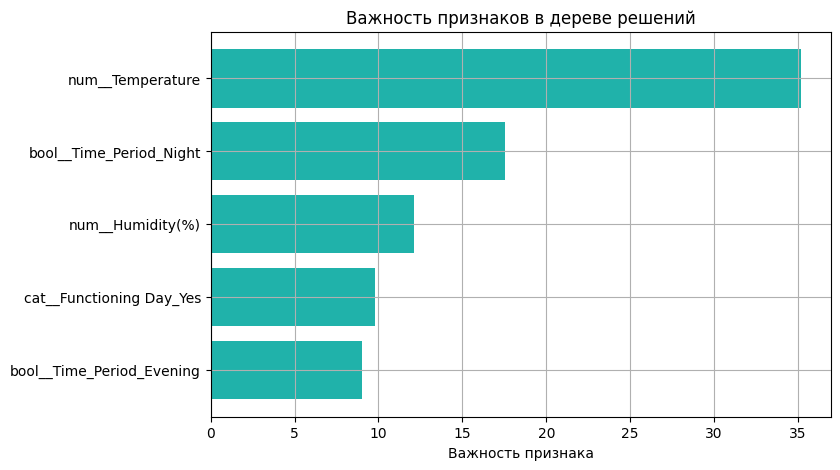

In [123]:
def evaluate_final_model(name, pipeline):
    pipeline.fit(X_train_val, y_train_val)
    y_pred = pipeline.predict(X_test)

    test_row = {
        "Phase": "Test",
        "Model": name,
        "RMSE":  root_mean_squared_error(y_test, y_pred),
        "MAE":   mean_absolute_error(y_test, y_pred),
        "R2":    r2_score(y_test, y_pred),
        "WAPE%": compute_wape(y_test, y_pred),
    }

    display(pd.DataFrame([test_row]).round(2))
    
    _, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax_scatter)
    limits = [y_test.min(), y_test.max()]
    ax_scatter.plot(limits, limits, "--r", linewidth=2)
    ax_scatter.set(
        title=f"{name} - Actual vs Predicted (Test Set)",
        xlabel="Actual (y)",
        ylabel="Predicted (ŷ)",
    )
    ax_scatter.grid(True)

    errors = y_test - y_pred
    sns.histplot(errors, kde=True, bins=30, ax=ax_hist)
    ax_hist.axvline(0, color="red", linestyle="--")
    ax_hist.set(
        title=f"{name} - Распределение ошибок",
        xlabel="Error (y − ŷ)",
    )

    plt.tight_layout()
    plt.show()

    show_tree_plot(name, pipeline)
    show_feature_importance(pipeline)
    
    return pipeline

final_model = evaluate_final_model('Decision Tree', tree_pipeline)

---

#### Выводы:

Вот итоговый анализ работы, разбитый на логические блоки для удобства чтения заказчиком.

**Выбор оптимальной модели**

С технической точки зрения, наилучший результат показал алгоритм Random Forest (случайный лес). Он дает самую низкую ошибку (RMSE около 282) и объясняет 81% закономерностей в данных. Однако, так как эта тема еще не изучалась в рамках курса, данная модель в финальное решение не войдет.

В качестве итоговой модели выбрано дерево решений (Decision Tree) с подобранными гиперпараметрами.
Оно показало себя значительно лучше, чем линейная регрессия (MSE 321 против 414) и метод ближайших соседей. Эта модель обеспечивает оптимальный баланс между точностью и понятностью интерпретации результатов.

**Что влияет на спрос (Ключевые факторы)**

Модель выделила конкретные показатели, которые сильнее всего определяют, сколько велосипедов возьмут в прокат:

1.  **Температура (35.18%)** - это самый важный фактор. Спрос критически зависит от того, тепло на улице или холодно.
2. **Время суток (суммарно более 31,31%)** - факторы "Ночь" (17.56%), "Вечер" (9.01%) и "Поздний вечер" (4.74%) идут следом. Люди активно пользуются сервисом после работы и для прогулок как перед сном, так уже и ночью.
3.  **Влажность (12.10%)** - Высокая влажность снижает комфорт езды, поэтому люди реже катаются. Ясная, солнечная погода дополнительно стимулирует спрос.
4.  **Рабочий статус системы (9.77%)** - признак "Functioning Day" показывает, что технические перерывы или выходные дни сервиса кардинально меняют картину потребления.

**Бизнес-вывод**

Для планирования загрузки станций следует опираться в первую очередь на **температурный прогноз**.
*   Модель чувствительна к теплу: ожидайте резкий рост аренды в теплые дни.
*   Вечерний-ночной пик: готовьте максимальное количество исправных велосипедов к временному слоту после 18:00, так как это самое активное время использования.
*   График работы персонала: В дни с хорошим прогнозом погоды стоит выводить больше сотрудников техподдержки и сервиса, так как нагрузка на систему гарантированно вырастет.

---

In [124]:
model_file_name = './models/new_model.joblib'

metadata = {
    'model_version': '1.0.0',
    'training_date': '2026-02-13',
    'best_score': tree_best_value,
    'best_params': tree_best_params,
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__
}

joblib.dump({
    'pipeline': final_model,
    'metadata': metadata,
}, model_file_name)

print(f"Объект сохранён в файл {model_file_name}") 

Объект сохранён в файл ./models/new_model.joblib


In [125]:
class SouthernWeatherPredictionService:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)

    def predict_forecasting(self, data):
        return self.model['pipeline'].predict(data)

In [126]:
service = SouthernWeatherPredictionService(model_file_name)
result = service.predict_forecasting(test)

submission = pd.DataFrame({
    'Rented Bike Count': result
})

submission.to_csv('datasets/submissions.csv', index=False)